# Example 1 — a train of ten pulses on `dac_0`

This notebook drives the **real control software against the Verilated `PulseTableSoc`** (cocotb
co-simulation, [`docs/software/06`](../docs/software/06-cosim.md)) and plays a sequence of **ten gate
pulses with linearly increasing amplitude** on physical **DAC 0** — qubit core 0's gate-drive channel.

The pulse sequence is written **right here in the notebook** with the production
[`Program`](../software/python/riscq/program.py) DSL, in physical units (Hz, seconds, amplitude in
[-1, 1]); it compiles to a RISC-V ELF the core runs itself, exactly as on the ZCU216 board. The
harness loads it, captures physical DAC 0 every dsp cycle, and we plot the waveform.

> The DUT is `CosimExampleGen` — the same 2-qubit `PulseTableSoc` the Scala sims sign off, but with
> core 0 wired to its production converters (DAC 0 / ADC 14), so the notebook uses those ports by their
> board names. Building + Verilating it the first time takes ~1–2 minutes.

In [1]:
%matplotlib inline
import os, sys
# locate software/python (the riscq package) by walking up from the notebook's directory
_root = os.path.abspath("")
while _root != "/" and not os.path.isdir(os.path.join(_root, "software", "python", "riscq")):
    _root = os.path.dirname(_root)
sys.path.insert(0, os.path.join(_root, "software", "python"))

import numpy as np
import matplotlib.pyplot as plt
from riscq import Program, pulse
from riscq.socconfig import default_config
from riscq.cosim import build, runner

cfg = default_config(qubit_num=2)            # the 2-qubit example DUT (core 0 on DAC 0 / ADC 14)
WORK = build.EXAMPLE_BUILD_DIR
os.makedirs(WORK, exist_ok=True)
print("riscq:", os.path.dirname(build.__file__))
print("fs =", cfg.fs / 1e9, "GSPS,  batch_size =", cfg.batch_size)

riscq: /config/build/agentic-rv-dev/software/python/riscq/cosim
fs = 8.0 GSPS,  batch_size = 16


## The pulse program

Ten gate pulses, one shared Gaussian envelope, amplitude swept from 0.10 to 0.55. The `Program` DSL
deduplicates pulse definitions and lowers each launch to a `set_start_time` + `fire`. Two hardware
facts shape the schedule:

- the gate pulse generator's parameter pipeline is ~50 batches deep and its launch queue holds only 4,
  so we **pace** the launches with `sleep_until` (fire ~1–2 pulses ahead) and space them 96 batches;
- ten distinct amplitudes exceed the gate table's 4 slots, so the DSL reprograms a slot before each
  later fire — the harmless `pulse spills` warnings you'll see.

In [2]:
# ---- the pulse program: ten gate pulses on dac_0 with linearly increasing amplitude ----
N_PULSES  = 10
F_CARRIER = 250e6        # gate carrier (~5 cycles per pulse)
WIDTH     = 20e-9        # pulse / envelope length  (= 10 batches at fs = 8 GSPS)
SPACING   = 192e-9       # centre-to-centre spacing (= 96 batches)
LEAD      = 96           # batches of head-room before the first pulse
AMPS      = np.linspace(0.10, 0.55, N_PULSES)   # amplitudes; < 0.6 keeps the product under full scale
                                                #   (the generator runs the CORDIC un-gain-corrected,
                                                #    K ~ 1.65, and the datapath is saturate=false)

prog = Program(cfg, lead=LEAD, core=0)
env = pulse.gaussian(WIDTH, cfg.fs)             # one shared Gaussian, scaled by `amp` for each pulse
for i, amp in enumerate(AMPS):
    t = i * SPACING
    prog.play("gate", t=t, freq=F_CARRIER, phase=0.0, amp=float(amp), dur=WIDTH,
              env=(env if i == 0 else 0))       # load the envelope once (line 0), reference it after
    prog.sleep_until(t)                          # pace: wait until this pulse plays before the next fire

print("requested amplitudes:", np.round(AMPS, 3))
print("schedule:")
print("\n".join("  " + l.strip() for l in prog.emit_c().splitlines()
                 if "set_start_time" in l or "fire" in l))

channel gate exceeded pulseNum=4 — pulse spills (reprogrammed per fire)


channel gate exceeded pulseNum=4 — pulse spills (reprogrammed per fire)


channel gate exceeded pulseNum=4 — pulse spills (reprogrammed per fire)


channel gate exceeded pulseNum=4 — pulse spills (reprogrammed per fire)


channel gate exceeded pulseNum=4 — pulse spills (reprogrammed per fire)


channel gate exceeded pulseNum=4 — pulse spills (reprogrammed per fire)


requested amplitudes: [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55]
schedule:
  set_start_time(GATE, t0 + 96); fire(GATE, 0);
  set_start_time(GATE, t0 + 192); fire(GATE, 1);
  set_start_time(GATE, t0 + 288); fire(GATE, 2);
  set_start_time(GATE, t0 + 384); fire(GATE, 3);
  set_start_time(GATE, t0 + 480); fire(GATE, 0);
  set_start_time(GATE, t0 + 576); fire(GATE, 1);
  set_start_time(GATE, t0 + 672); fire(GATE, 2);
  set_start_time(GATE, t0 + 768); fire(GATE, 3);
  set_start_time(GATE, t0 + 864); fire(GATE, 0);
  set_start_time(GATE, t0 + 960); fire(GATE, 1);


## Compile and run the co-simulation

Compile the program to an ELF, hand the harness the ELF + the envelope it needs + the capture settings,
elaborate/Verilate the DUT, and run the capture test (`riscq.cosim.cocotb_dac_capture`).

In [3]:
elf = prog.build(WORK, name="pulse_train")
JOB = runner.save_job(os.path.join(WORK, "pulse_train_job.pkl"),
                      elf=elf, envelopes=prog.envelopes(), dac_phys=0, capture_batches=1400)
OUT = os.path.join(WORK, "pulse_train.npz")
os.environ["RISCQ_COSIM_JOB"] = JOB
os.environ["RISCQ_COSIM_OUT"] = OUT

build.generate_example_rtl()                                  # CosimExampleGen -> rtl_examples/
runner.build_and_run("riscq.cosim.cocotb_dac_capture",
                     rtl_dir=build.EXAMPLE_RTL_DIR, build_dir=build.EXAMPLE_BUILD_DIR)

data = np.load(OUT)
print("captured", data["dac"].size, "DAC samples")

- V e r i l a t i o n   R e p o r t: Verilator 5.032 2025-01-01 rev v5.032
     0.00ns INFO     cocotb                             Running on Verilator version 5.032 2025-01-01
     0.00ns INFO     cocotb                             Running tests with cocotb v1.9.2 from /config/build/agentic-rv-dev/software/python/.venv/lib/python3.12/site-packages/cocotb
     0.00ns INFO     cocotb.regression                  Found test riscq.cosim.cocotb_dac_capture.capture_dac
     0.00ns INFO     cocotb.regression                  running capture_dac (1/1)


  from cocotb.runner import get_runner


109880.00ns INFO     cocotb.PulseTableSoc               captured DAC 0: 22400 samples, peak |amp|=29669
109880.00ns INFO     cocotb.regression                  capture_dac passed
109880.00ns INFO     cocotb.regression                  ****************************************************************************************************
                                                        ** TEST                                        STATUS  SIM TIME (ns)  REAL TIME (s)  RATIO (ns/s) **
                                                        ****************************************************************************************************
                                                        ** riscq.cosim.cocotb_dac_capture.capture_dac   PASS      109880.00           0.77     142365.01  **
                                                        ****************************************************************************************************
                                    

## Plot `dac_0`

The full train (top), a zoom on the largest pulse showing the Gaussian envelope riding the carrier
(bottom-left), and the measured peak vs the requested amplitude — a straight line (bottom-right).

found 10 pulses; peaks = [5394, 8092, 10790, 13486, 16183, 18882, 21577, 24276, 26973, 29669]


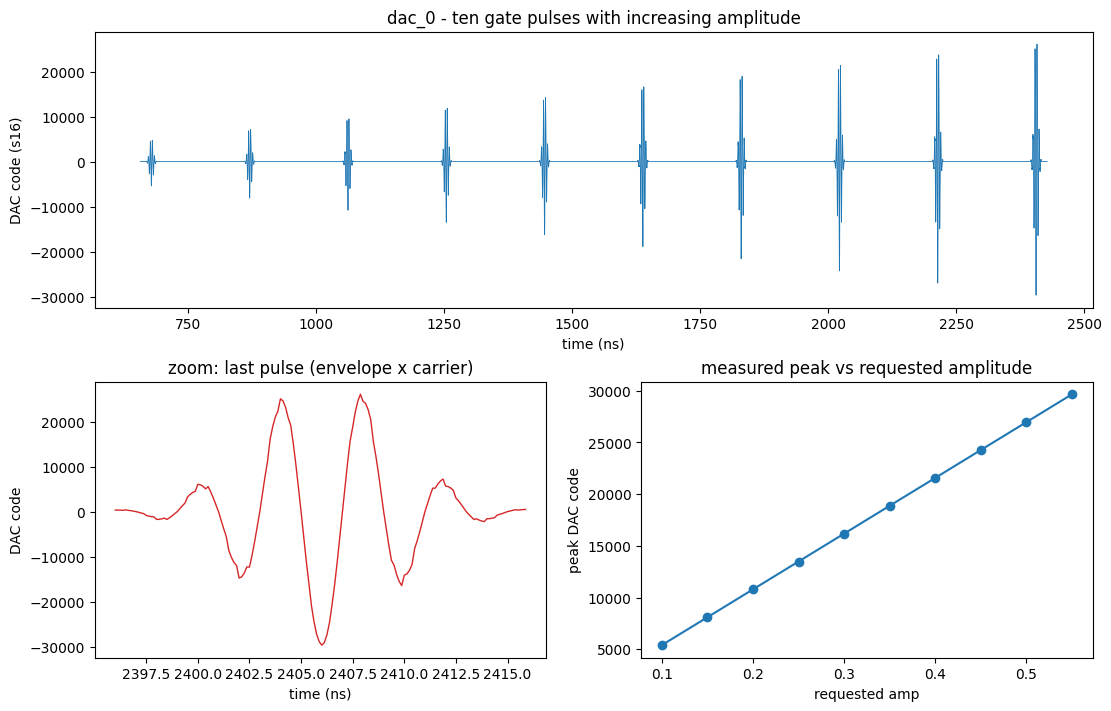

In [4]:
w = data["dac"]; bs = int(data["batch_size"]); fs = float(data["fs"])
peak_b = np.abs(w.reshape(-1, bs)).max(axis=1)              # peak magnitude per batch

# group consecutive non-zero batches into bursts (one per pulse) and measure each peak
bursts, i = [], 0
while i < len(peak_b):
    if peak_b[i] > 0:
        j = i
        while j < len(peak_b) and peak_b[j] > 0:
            j += 1
        bursts.append((i, j)); i = j
    else:
        i += 1
peaks = [int(np.abs(w[a*bs:b*bs]).max()) for a, b in bursts]
print(f"found {len(bursts)} pulses; peaks =", peaks)

b0, b1 = bursts[0][0], bursts[-1][1]
s0, s1 = max(0, b0 - 6) * bs, (b1 + 6) * bs
t = np.arange(s0, s1) / fs * 1e9

fig = plt.figure(figsize=(11, 7), constrained_layout=True)
gs = fig.add_gridspec(2, 2)
ax = fig.add_subplot(gs[0, :])
ax.plot(t, w[s0:s1], lw=0.6)
ax.set(title="dac_0 - ten gate pulses with increasing amplitude",
       xlabel="time (ns)", ylabel="DAC code (s16)")

za, zb = bursts[-1]
zt = np.arange(za * bs, zb * bs) / fs * 1e9
axz = fig.add_subplot(gs[1, 0])
axz.plot(zt, w[za*bs:zb*bs], lw=1.0, color="C3")
axz.set(title="zoom: last pulse (envelope x carrier)", xlabel="time (ns)", ylabel="DAC code")

axl = fig.add_subplot(gs[1, 1])
axl.plot(AMPS, peaks, "o-")
axl.set(title="measured peak vs requested amplitude", xlabel="requested amp", ylabel="peak DAC code")
plt.show()

**What we see.** Ten Gaussian-modulated bursts on DAC 0, each a clean envelope × carrier, with peak
amplitude rising linearly across the train — the increasing-amplitude sequence the program scheduled,
played by the RISC-V core through the real RF datapath of the Verilated SoC.